In [1]:
import matplotlib
matplotlib.rcParams.update({'legend.fontsize': 14, 'legend.handlelength': 2})
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style ="whitegrid", font_scale=1.5)
import pandas as pd

/home/albert/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


#### Load `uam_system_model` dependencies

In [2]:
from uam_system_model.StarNetwork import StarNetwork
from uam_system_model.FleetOpVRP import FleetOpVRP
from uam_system_model.utils.visualize import plot_hourly_flight_distribution, plot_parameters

#### Prepare input

In [3]:
def calculate_distances_in_meters(coords):
    num_points = len(coords)
    distance_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).meters/1600
    return distance_matrix

import numpy as np
from geopy.distance import geodesic
coordinates = np.array([(33.94417072663332, -118.40248449470265),
                        (34.043119432990345, -118.26720629762752),
                        (33.81606030845284, -118.15122129260827),
                        (34.17160155814583, -118.60525790222589),
                        (34.13843197335217, -118.35511311047983),
                        (33.812102161009804, -117.91897753216998),
                        (34.09174681098575, -118.32725521957076),
                        (34.08807589928915, -118.55063573741867),
                        (34.06666969690935, -118.4114352069469)])
                        
distance_matrix = calculate_distances_in_meters(coordinates)
vertiports = ['LAX', 'DTLA', 'LGB', 'WDHL', 'UVS', 'ANH', 'HWD', 'PSD', 'BVH']

vertiport_pmf = np.array([0, 6.1, 3.3, 1.5, 1.5, 5.4, 4.3, 2.5, 2.2])
vertiport_pmf = vertiport_pmf / vertiport_pmf.sum()

flight_time_matrix = np.load("uam_system_model/data/config/flight_time_matrix.npy")
energy_consumption_matrix = np.load("uam_system_model/data/config/energy_consumption_matrix.npy")

#### Create instance variable

In [4]:
network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=distance_matrix,
    flight_time_matrix=flight_time_matrix,
    energy_consumption_matrix=energy_consumption_matrix,
)

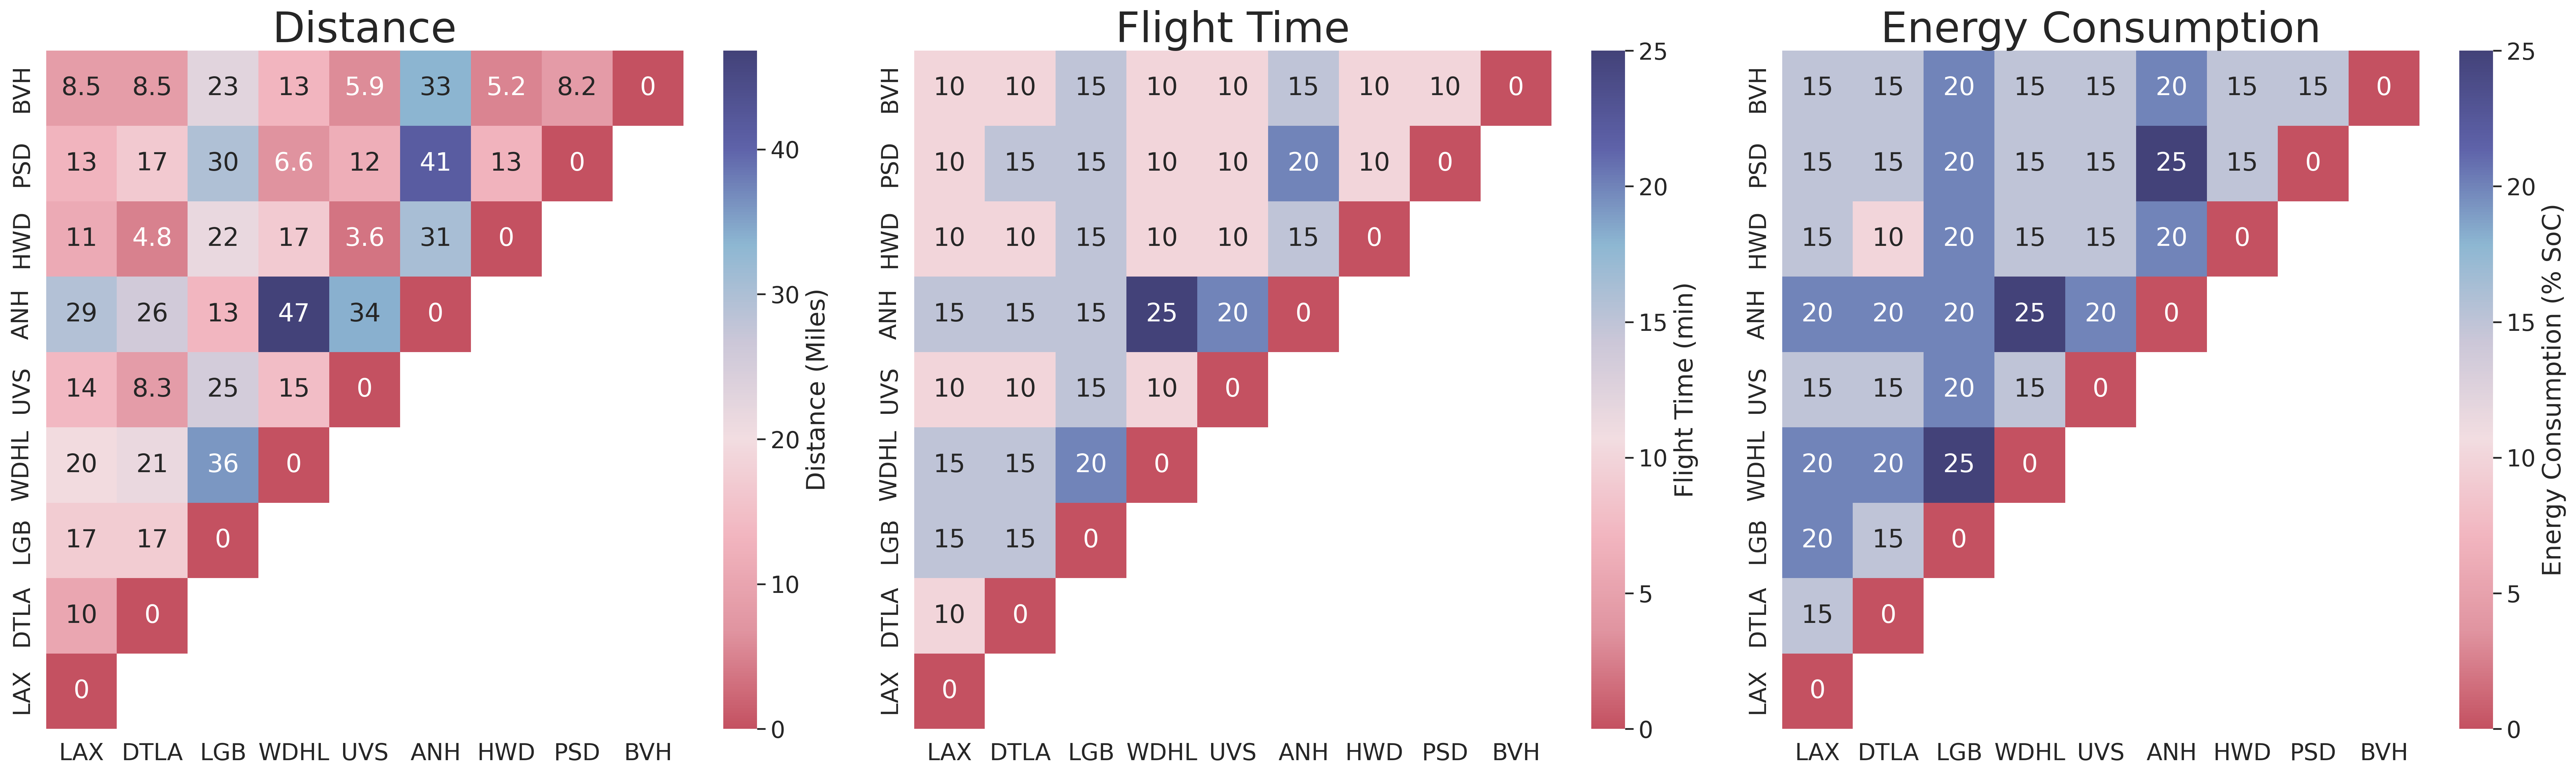

In [5]:
plot_parameters(network);

#### Load demand & visualize

In [ ]:
network.load_demand(
    month=8,
    day=1,
    directional_demand=300,
    vertiport_pmf=vertiport_pmf,
)
network.schedule

,schedule,od,num_pax,revenue
0,5.000000,LAX_BVH,1,25.524422
1,7.138757,LAX_WDHL,1,58.902360
2,10.373664,LAX_LGB,1,51.083877
3,19.519868,LAX_LGB,1,51.083877
4,29.548101,LAX_BVH,1,25.524422
...,...,...,...,...
323,1414.233033,LAX_DTLA,1,31.188102
324,1415.776418,LAX_LGB,1,51.083877
325,1426.089879,LAX_UVS,1,41.226701
326,1427.260387,ANH_LAX,1,88.256047


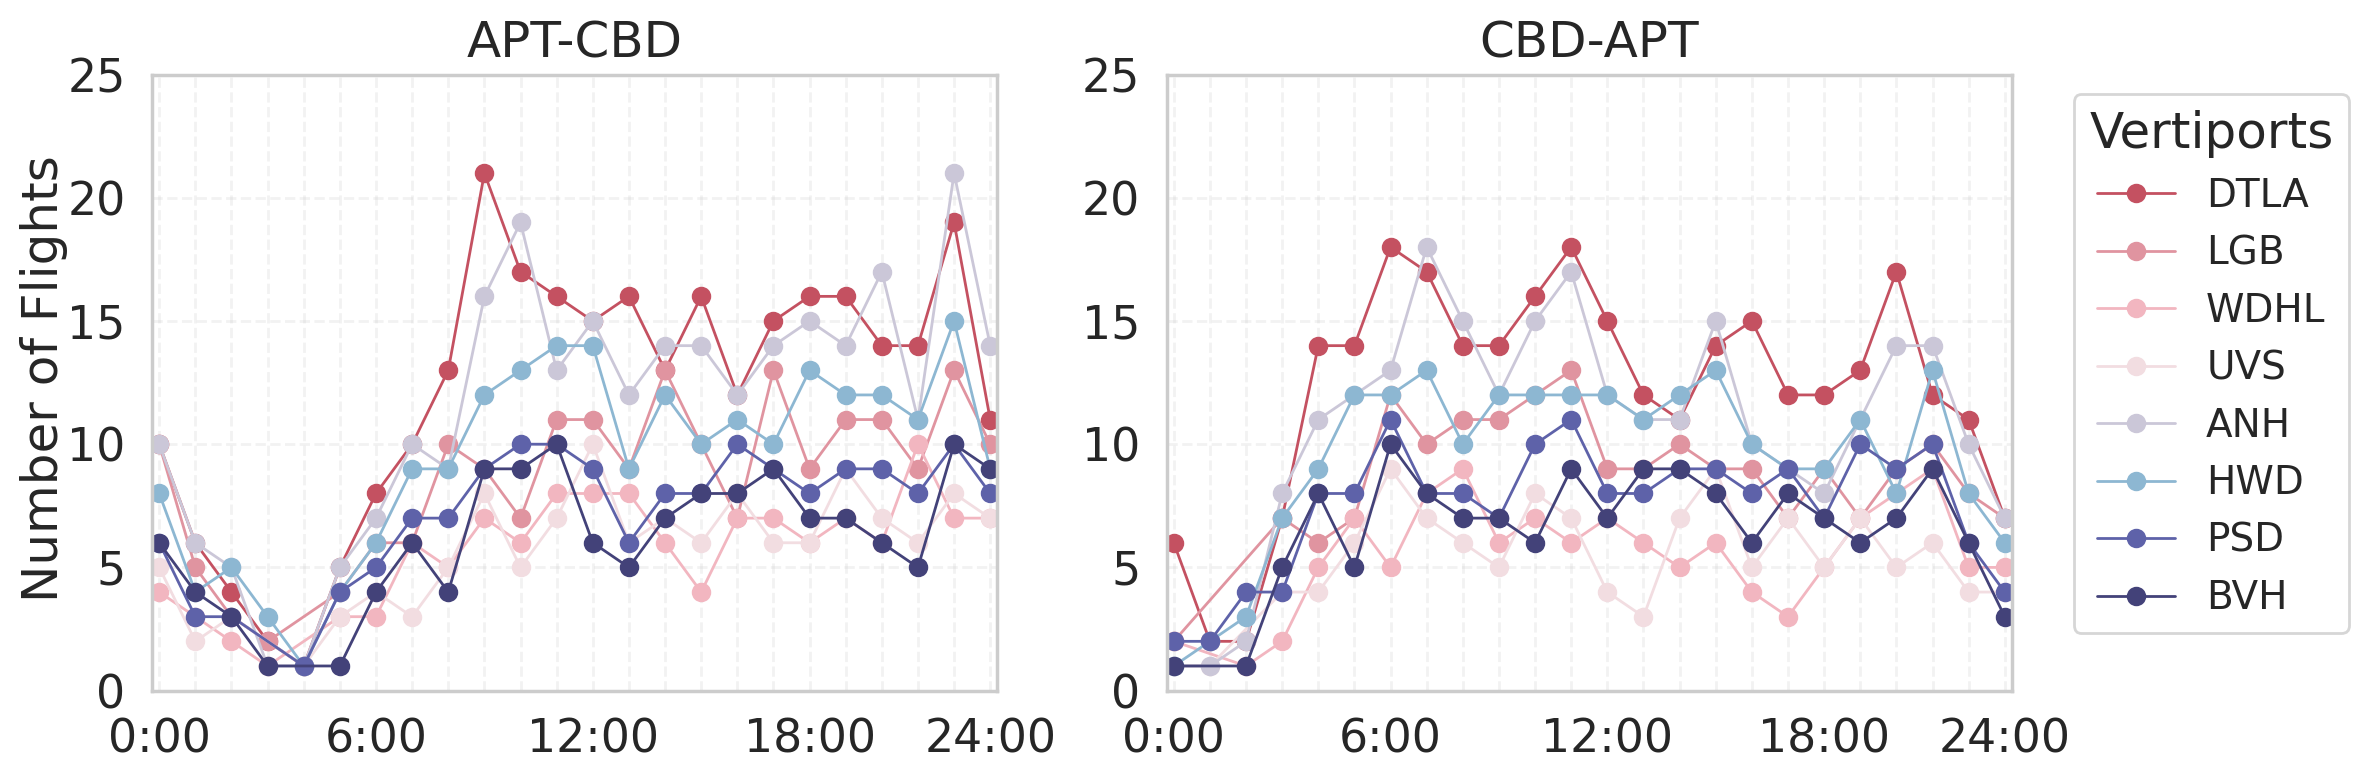

In [6]:
fig, ax = plot_hourly_flight_distribution(network, ylim=(0, 25))
plt.show()

#### Run VRP Optimization

In [6]:
vrp = FleetOpVRP(StarNetwork=network)
unserved_tours, served_tours = vrp.optimize(15, 3, 0.7, n_processes=20, verbose=True)

INFO - 2025-07-04 22:49:35,678 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [1] BUILDING SUBTOURS
INFO - 2025-07-04 22:49:38,304 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [2] SOLVING KNAPSACK PROBLEM


Set parameter Username
Academic license - for non-commercial use only - expires 2025-10-30


INFO - 2025-07-04 22:49:38,414 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF FLIGHTS BEFORE: 328 NUMBER OF TOURS AFTER: 328
INFO - 2025-07-04 22:49:38,415 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [3] SOLVING THE CLUSTERING/SCHEDULING PROBLEM
100%|██████████| 658/658 [00:02<00:00, 226.36it/s]
INFO - 2025-07-04 22:49:42,205 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF FLIGHTS SELECTED AFTER CLUSTERING: 328/328
INFO - 2025-07-04 22:49:42,208 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [4] SOLVING 1-VRP


TOURS SERVED: 3/3
FLIGHTS SERVED: 3/3
TOURS SERVED: 2/2
FLIGHTS SERVED: 2/2
TOURS SERVED: 7/9
FLIGHTS SERVED: 7/9
TOURS SERVED: 19/21
FLIGHTS SERVED: 19/21
TOURS SERVED: 19/21
FLIGHTS SERVED: 19/21
TOURS SERVED: 27/31
FLIGHTS SERVED: 27/31
TOURS SERVED: 12/14
FLIGHTS SERVED: 12/14
TOURS SERVED: 20/25
FLIGHTS SERVED: 20/25
TOURS SERVED: 27/33
FLIGHTS SERVED: 27/33
TOURS SERVED: 27/33
FLIGHTS SERVED: 27/33
TOURS SERVED: 17/20
FLIGHTS SERVED: 17/20
TOURS SERVED: 20/28
FLIGHTS SERVED: 20/28
TOURS SERVED: 18/22
FLIGHTS SERVED: 18/22
TOURS SERVED: 29/37
FLIGHTS SERVED: 29/37
TOURS SERVED: 24/29
FLIGHTS SERVED: 24/29


INFO - 2025-07-04 23:07:55,919 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF SERVED FLIGHTS: 271 / 328
INFO - 2025-07-04 23:07:55,920 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [5] Iterative Insertion
INFO - 2025-07-04 23:07:55,921 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF SERVED FLIGHTS: 271 / 328


TOURS SERVED: 30/60
FLIGHTS SERVED: 30/60
TOURS SERVED: 27/47
FLIGHTS SERVED: 27/47
TOURS SERVED: 25/38
FLIGHTS SERVED: 25/38
TOURS SERVED: 30/40
FLIGHTS SERVED: 30/40
TOURS SERVED: 25/29
FLIGHTS SERVED: 25/29
TOURS SERVED: 27/28
FLIGHTS SERVED: 27/28
TOURS SERVED: 19/20
FLIGHTS SERVED: 19/20
TOURS SERVED: 20/21
FLIGHTS SERVED: 20/21
TOURS SERVED: 30/30
FLIGHTS SERVED: 30/30
TOURS SERVED: 27/27
FLIGHTS SERVED: 27/27
TOURS SERVED: 20/20
FLIGHTS SERVED: 20/20
TOURS SERVED: 27/27
FLIGHTS SERVED: 27/27
TOURS SERVED: 7/7
FLIGHTS SERVED: 7/7


INFO - 2025-07-04 23:20:23,053 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - OPTIMIZATION COMPLETE
INFO - 2025-07-04 23:20:23,054 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - TOTAL NUMBER OF SERVED FLIGHTS: 328


TOURS SERVED: 12/12
FLIGHTS SERVED: 12/12
TOURS SERVED: 2/2
FLIGHTS SERVED: 2/2
